<a href="https://colab.research.google.com/github/heisenberg304/aprendiendo-ml-cloud/blob/semana-4/dia2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#librerias
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
#dividir test y train
x = np.array([[1.4,0.2],[1.5,0.2],[1.3,0.2],[1.6,0.3],[1.4,0.3],[1.7,0.2],[1.5,0.4],[1.4,0.2],[1.6,0.2],[1.5,0.3],[4.5,1.5],[4.7,1.4],[4.6,1.3],[5.0,1.5],[4.9,1.5],[4.2,1.3],[4.4,1.4],[5.1,1.6],[4.8,1.4],[5.0,1.7]]) #petal_length
y = np.array(["setosa","setosa","setosa","setosa","setosa","setosa","setosa","setosa","setosa","setosa","no_setosa","no_setosa","no_setosa","no_setosa","no_setosa","no_setosa","no_setosa","no_setosa","no_setosa","no_setosa"]) #label
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2
)

#crear modelo
model = LogisticRegression() #si vas a poner C es en mayuscula

#entrenar modelo
model.fit(x_train,y_train)   #fit() hace literalmente casi lo mismo que el algoritmo que hice anteriormente pero no usando regresion lineal sino regresion logistica (el modelo calcula z = x·w + b y aplica la función sigmoid para obtener probabilidades), que se parece pero en vez de MSE usamos log loss (binary cross entropy))

#hacer predicciones
pred = model.predict(x_test) #predict no aprende nada, solo usa lo aprendido para predecir con valores nuevos, usando xw+b y luego sigmoid para que con lo aprendido clasifique los nuevos valores

#inferencia
nuevo_dato = [[1.6,0.3]] #necesario el doble corchete [[]]
nuevo = model.predict(nuevo_dato)

#metrica accuracy
accuracy = accuracy_score(y_test, pred)

#matriz de confusion                       [[TN FP]
confusion = confusion_matrix(y_test, pred)#[FN TP]]

print(confusion)
print(accuracy)

[[1 0]
 [0 3]]
1.0


iter 1, 0.005 ----> 0.005124125             -0.5 ----> -0.49999995291666666
0.3039583333333332
iter 2, 0.005124125 ----> 0.005169435782161458             -0.49999995291666666 ----> -0.4999999252278693
0.19880221582416635
iter 3, 0.005169435782161458 ----> 0.005185976096946898             -0.4999999252278693 ----> -0.4999999046188844
0.18478959455005098
iter 4, 0.005185976096946898 ----> 0.005192013994583059             -0.4999999046188844 ----> -0.49999988659432576
0.18292233288434098
iter 5, 0.005192013994583059 ----> 0.005194218073166651             -0.49999988659432576 ----> -0.4999998695131904
0.18267350551302183
iter 6, 0.005194218073166651 ----> 0.005195022648348415             -0.4999998695131904 ----> -0.49999985277644404
0.182640343189895
iter 7, 0.005195022648348415 ----> 0.005195316346583491             -0.49999985277644404 ----> -0.4999998361654142
0.18263591939089266
iter 8, 0.005195316346583491 ----> 0.005195423553485774             -0.4999998361654142 ----> -0.4999998196

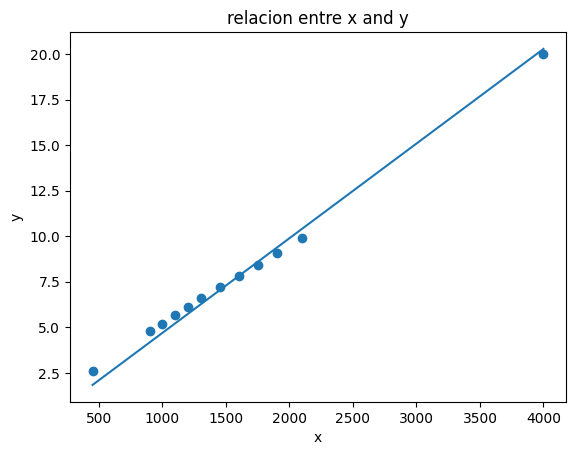

iter 1000, 0.00519547712575317 ----> 0.005195477117613671             -0.4999834298672782 ----> -0.4999834133289027
0.18262980791662078


In [6]:
import numpy as np
import matplotlib.pyplot as plt

#dataset
x = np.array([450, 900, 1000, 1100, 1200, 1300, 1450, 1600, 1750, 1900, 2100, 4000]) #peso en kg
y = np.array([2.6, 4.8, 5.2, 5.7, 6.1, 6.6, 7.2, 7.8, 8.4, 9.1, 9.9, 20]) #consumo en L/1000mk

#valoree
w = 0.005
b = -0.5
a = 0.0000001

#gradiente
def loss(w, b):
  #prediccion
  y_hat = x*w + b

  #error
  error = y_hat - y

  #funcion de error
  L = sum((error)**2)/len(x)

  #derivada de mse respecto a w and b
  Lw = sum(2*x*(error))/len(x)
  Lb = sum(error)/len(x)
  return (Lw, Lb, L)

def graficar(w,b):
  x_values = np.arange(450, 4001).reshape(-1, 1)
  y_values = x_values*w + b
  plt.scatter(x, y)
  plt.plot(x_values, y_values)
  plt.xlabel("x")
  plt.ylabel("y")
  plt.title('relacion entre x and y')
  plt.show()

for epoch in range(1000):
  W = w
  B = b
  grad_w, grad_b, L = loss(w, b)
  w = w - a*(grad_w)
  b = b - a*(grad_b)
  if epoch == 999:
     (graficar(w, b))
  else:
    pass

  print(f"iter {epoch+1}, {W} ----> {w}             {B} ----> {b}")
  print(f"{L}")


